### Questão 2

**Enunciado:** Uma empresa de TI precisa precificar seus projetos de software. O valor do projeto depende da quantidade de desenvolvedores alocados, da duração do projeto em meses e da complexidade tecnológica (medida em uma escala de 1 a 10). Utilize o algoritmo que suporte múltiplas variáveis preditoras para encontrar o preço justo de um projeto com 5 Devs, 8 meses e complexidade 7. Demonstre os coeficientes encontrados. 

**Problema:** Estimar o preço de projetos de software baseando-se em devs alocados, meses de duração e nível de complexidade.

**Algoritmo Apropriado:** ``Regressão Linear Múltipla``.

**Justificativa:** Trata-se de um problema de previsão de um valor contínuo (preço) que depende de duas ou mais variáveis independentes (features). Diferente da regressão simples, a regressão múltipla irá ajustar um hiperplano no espaço multidimensional com base na Solução Clássica (Equação Normal) para encontrar o vetor de pesos $\beta$.

#### **Importando as bibliotecas**

In [16]:
import numpy as np
import matplotlib.pyplot as plt

#### **Carregamento do Dataset**

In [17]:
try:
    # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows=1
    dados = np.loadtxt('datasets/dataset_q2.csv', delimiter=',', skiprows=1)

    # X_features: Colunas -> [Devs, Meses, Complexidade]
    X_features = dados[:, :3]
    y = dados[:, 3]

    # Visualiza os dados
    print("X:", X_features)
    print("y:", y)

    print("\n Número de amostras:", X_features.shape[0])

except FileNotFoundError:
    print("Erro: Arquivo do dataset não encontrado.")
    exit()

X: [[ 2.  3.  2.]
 [ 3.  4.  3.]
 [ 5.  6.  5.]
 [ 2.  2.  4.]
 [ 8. 12.  8.]
 [ 4.  5.  3.]
 [ 6.  8.  6.]
 [ 3.  3.  2.]
 [10. 18.  9.]
 [ 7. 10.  7.]
 [ 2.  5.  3.]
 [ 5.  7.  4.]
 [ 4.  4.  5.]
 [ 9. 15.  8.]
 [ 6.  9.  5.]]
y: [ 45.  68. 115.  48. 240.  82. 145.  55. 380. 195.  60. 110.  88. 310.
 155.]

 Número de amostras: 15


#### **Preparação das Matrizes e Cálculo dos Coeficientes (Betas)**

In [ ]:
# Adicionando o termo de Intercepto (Viés/Bias) representado por uma coluna de 1s
m = X_features.shape[0]
X = np.c_[np.ones(m), X_features]

# Aplicando a Equação Normal: Beta = (X.T * X)^-1 * X.T * Y
X_T = X.T
beta = np.linalg.inv(X_T @ X) @ X_T @ y

print("=== Coeficientes Descobertos ===")
print(f"Intercepto (Beta 0): {beta[0]:.2f}")
print(f"Peso para Devs (Beta 1): {beta[1]:.2f}")
print(f"Peso para Meses (Beta 2): {beta[2]:.2f}")
print(f"Peso para Complexidade (Beta 3): {beta[3]:.2f}\n")

=== Coeficientes Descobertos ===
Intercepto (Beta 0): -33.69
Peso para Devs (Beta 1): 1.25
Peso para Meses (Beta 2): 17.37
Peso para Complexidade (Beta 3): 7.81



#### **Realizando a Previsão do Desafio**

In [ ]:
# Prever: 5 Devs, 8 meses, complexidade 7
projeto_teste = np.array([1, 5, 8, 7]) # Lembre-se de adicionar o '1' do intercepto
preco_previsto = projeto_teste @ beta

print("=== Teste de Previsão ===")
print(f"Preço PREVISTO pelo modelo para o novo projeto: R$ {preco_previsto:.2f} mil")

=== Teste de Previsão ===
Preço PREVISTO pelo modelo para o novo projeto: R$ 166.21 mil


#### **Gráfico: Avaliando o Ajuste (Preço Real vs Preço Previsto)**

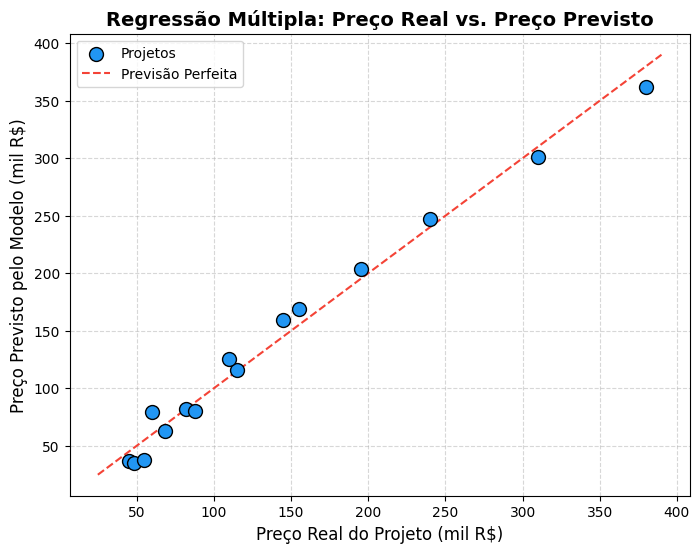

In [ ]:
y_previsto_todos = X @ beta 

plt.figure(figsize=(8, 6))

# Plota os pontos reais vs previstos
plt.scatter(y, y_previsto_todos, color='#2196F3', label='Projetos', s=100, zorder=5, edgecolor='black')

# Reta de previsão perfeita (onde y_real == y_previsto)
min_val = min(min(y), min(y_previsto_todos)) - 10
max_val = max(max(y), max(y_previsto_todos)) + 10
plt.plot([min_val, max_val], [min_val, max_val], color='#F44336', linestyle='--', label='Previsão Perfeita')

plt.title('Regressão Múltipla: Preço Real vs. Preço Previsto', fontsize=14, fontweight='bold')
plt.xlabel('Preço Real do Projeto (mil R$)', fontsize=12)
plt.ylabel('Preço Previsto pelo Modelo (mil R$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Interpretação dos Resultados**
O vetor $\beta$ gerado pela Equação Normal distribui o peso de impacto de cada variável independente no preço do projeto. 

Os coeficientes ($\beta_1, \beta_2, \beta_3$) indicam matematicamente a mudança no preço final para cada aumento unitário em uma *feature* específica, assumindo que as demais permaneçam constantes. O modelo processou adequadamente a relação matricial e, como ilustrado no gráfico "Previsão vs Real", os pontos se ajustam à linha tracejada de previsão perfeita, indicando uma forte capacidade explicativa das múltiplas variáveis fornecidas.